In [2]:
import sys
import numpy as np
from pathlib import Path
import scipy.io
from OMPython import ModelicaSystem

repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))
from docs.plot_setup import set_professional_style
plt = set_professional_style()


**Generate FMUComponents**

In [3]:
from SysSimX.utilities.update_fmus import get_fmu_paths
from SysSimX.components.fmu_comp import FMUComponent

demo_dir_path = Path(repo_root / 'demos' / 'ControlledPendulum')
package_path = Path.cwd() / 'MyModels/Modelica/ControlledPendulum/'
fmu_output_dir = Path.cwd() / 'MyModels/FMUs/'
fmu_paths = get_fmu_paths(package_path, fmu_output_dir, force_rebuild=False)

fmu_paths

All FMUs for package 'ControlledPendulum' already exist. Skipping generation.


{'AngleEncoder': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/AngleEncoder.fmu'),
 'Demo_Driven': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Demo_Driven.fmu'),
 'Demo_Driven_Coupled': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Demo_Driven_Coupled.fmu'),
 'Drive': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Drive.fmu'),
 'Drive_Coupled': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Drive_Coupled.fmu'),
 'Drive_QStat': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Drive_QStat.fmu'),
 'ImpactWall': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/ImpactWall.fmu'),
 'PID_Continuous': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/PID_Continuous.fmu'),
 'PID_Sampled': PosixPath('/home/flo/code/SystemSi

In [9]:
ref          = FMUComponent(name='ref', fmu_path=fmu_paths['Reference'], group='Input')
sensor_ref   = FMUComponent(name='sensor_ref', fmu_path=fmu_paths['AngleEncoder'], group='Sensors')
sensor_state = FMUComponent(name='sensor_state', fmu_path=fmu_paths['AngleEncoder'], group='Sensors')
pid          = FMUComponent(name='pid', fmu_path=fmu_paths['PID_Continuous'], group='Control')
#drive        = FMUComponent(name='Drive_Coupled', fmu_path=fmu_paths['Drive_Coupled'], group='Actuator')
drive        = FMUComponent(name='drive', fmu_path=fmu_paths['Drive'], group='Actuator')
pendulum     = FMUComponent(name='EQB_Pendulum', fmu_path=fmu_paths['Pendulum'], group='Plant')

fmu_list = [ref, sensor_ref, sensor_state, pid, drive, pendulum]
for fmu in fmu_list:
    print(fmu.name)
    print(" Direct Feedthrough:")
    for output, inputs in fmu.direct_feedthrough.items():
        print(f"  Output: {output} <- Inputs: {inputs}")
    print()

ref
 Direct Feedthrough:
  Output: q_ref <- Inputs: []

sensor_ref
 Direct Feedthrough:
  Output: U_q <- Inputs: ['q']

sensor_state
 Direct Feedthrough:
  Output: U_q <- Inputs: ['q']

pid
 Direct Feedthrough:
  Output: u <- Inputs: ['ref', 'y']

drive
 Direct Feedthrough:
  Output: torque <- Inputs: []

EQB_Pendulum
 Direct Feedthrough:
  Output: alpha <- Inputs: ['torque']
  Output: omega <- Inputs: []
  Output: q <- Inputs: []



**Define Connections**

In [10]:
from SysSimX.system.connection import Connection

c1 = Connection(src_comp=ref.name, src_port=ref.output_specs['q_ref'].name,
                dst_comp=sensor_ref.name, dst_port=sensor_ref.input_specs['q'].name)

c2 = Connection(src_comp=pendulum.name, src_port=pendulum.output_specs['q'].name,
                dst_comp=sensor_state.name, dst_port=sensor_state.input_specs['q'].name)

c3 = Connection(src_comp=sensor_ref.name, src_port=sensor_ref.output_specs['U_q'].name,
                dst_comp=pid.name, dst_port=pid.input_specs['ref'].name)

c4 = Connection(src_comp=sensor_state.name, src_port=sensor_state.output_specs['U_q'].name,
                dst_comp=pid.name, dst_port=pid.input_specs['y'].name)

c5 = Connection(src_comp=pid.name, src_port=pid.output_specs['u'].name,
                dst_comp=drive.name, dst_port=drive.input_specs['u_control'].name)

c6 = Connection(src_comp=drive.name, src_port=drive.output_specs['torque'].name,
                dst_comp=pendulum.name, dst_port=pendulum.input_specs['torque'].name)

c7 = Connection(src_comp=pendulum.name, src_port=pendulum.output_specs['omega'].name,
                dst_comp=drive.name, dst_port=drive.input_specs['omega'].name)

connections = [c1, c2, c3, c4, c5, c6, c7]
components = [ref, sensor_ref, sensor_state, pid, drive, pendulum]

**Define System**

In [11]:
from SysSimX.system.system import System

system = System(name="Controlled Pendulum System")

for comp in components:
    system.add_component(comp)

for conn in connections:
    system.add_connection(conn)

system.compute_execution_order()

**Create System Graph**

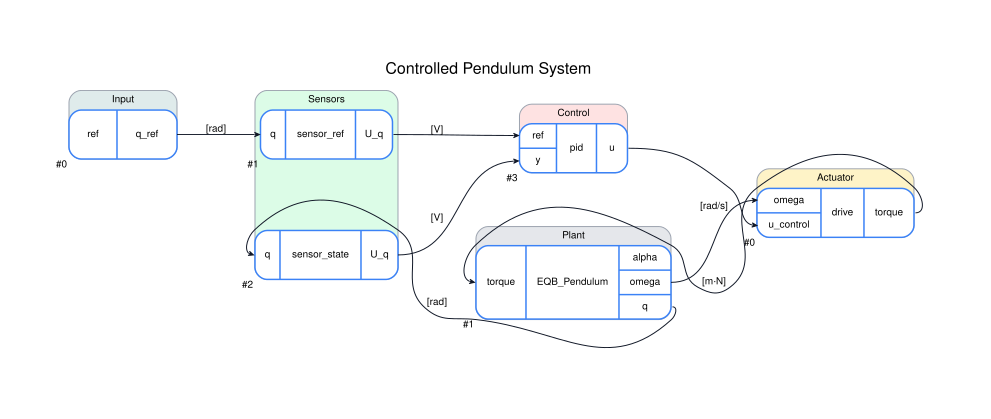

In [12]:
from SysSimX.viz.sysgraph import SystemGraphVisualizer
visualizer = SystemGraphVisualizer(system)
visualizer.visualize()
visualizer.save("figures/demo-2-8_syssimx_system_graph.svg")

**Setup Simulation Monitor**

In [13]:
t = 0.0
dt = 0.001
t_end = 5
system.initialize(t, t_end=t_end)
system.run(t, t_end, dt)

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_S

In [ ]:
num_steps = int(t_end / dt)

for step in range(num_steps):
    # 1) Pendulum update
    pendulum.do_step(t, dt)

    # 2) Sensor update
    ref.do_step(t, dt)
    sensor_ref.set_inputs({'q': ref.outputs['q_ref'].value}, t + dt)
    sensor_state.set_inputs({'q': pendulum.outputs['q'].value}, t + dt)
    sensor_ref.do_step(t, dt)
    sensor_state.do_step(t, dt)

    # 3) PID update
    pid.set_inputs({'ref': sensor_ref.outputs['U_q'].value,
                    'y': sensor_state.outputs['U_q'].value}, t + dt)
    pid.do_step(t, dt)

    # 4) Drive update
    drive.set_inputs({'u_control': pid.outputs['u'].value,
                    'omega': pendulum.outputs['omega'].value}, t + dt)
    drive.do_step(t, dt)

    # 5) Pendulum update with new torque
    pendulum.set_inputs({'torque': drive.outputs['torque'].value}, t + dt)

    #print(f"Time: {t+dt:.2f} s | Pendulum Angle: {pendulum.outputs['q'].value:.4f} rad")

    t += dt

Time: 0.00 s | Pendulum Angle: 0.0000 radian rad
Time: 0.00 s | Pendulum Angle: 0.0000 radian rad
Time: 0.00 s | Pendulum Angle: 0.0000 radian rad
Time: 0.00 s | Pendulum Angle: 0.0000 radian rad
Time: 0.01 s | Pendulum Angle: 0.0000 radian rad
Time: 0.01 s | Pendulum Angle: 0.0000 radian rad
Time: 0.01 s | Pendulum Angle: 0.0000 radian rad
Time: 0.01 s | Pendulum Angle: 0.0000 radian rad
Time: 0.01 s | Pendulum Angle: 0.0000 radian rad
Time: 0.01 s | Pendulum Angle: 0.0000 radian rad
Time: 0.01 s | Pendulum Angle: 0.0000 radian rad
Time: 0.01 s | Pendulum Angle: 0.0000 radian rad
Time: 0.01 s | Pendulum Angle: 0.0000 radian rad
Time: 0.01 s | Pendulum Angle: 0.0000 radian rad
Time: 0.02 s | Pendulum Angle: 0.0001 radian rad
Time: 0.02 s | Pendulum Angle: 0.0001 radian rad
Time: 0.02 s | Pendulum Angle: 0.0001 radian rad
Time: 0.02 s | Pendulum Angle: 0.0002 radian rad
Time: 0.02 s | Pendulum Angle: 0.0003 radian rad
Time: 0.02 s | Pendulum Angle: 0.0003 radian rad
Time: 0.02 s | Pendu

In [14]:
# Reference Modelica Simulation for Verification of the Co-Simulation Algorithm

# 1) Build the Modelica Model
pkg_dir_path = Path.cwd() / 'MyModels/Modelica/ControlledPendulum'
pkg_file_path = pkg_dir_path / 'package.mo'
model_file_path = pkg_dir_path / 'Demo_Driven.mo'
model = ModelicaSystem(str(pkg_file_path), 'ControlledPendulum.Demo_Driven')

# 2) Set Simulation Options, Build and Simulate
simulation_options = [
    f"startTime={0.0}",
    f"stopTime={t_end}",        
    f"stepSize={dt}",
    f"tolerance={1e-6}",
]
model.setOptimizationOptions(f"numberOfIntervals={int(t_end/dt)}")
model.setSimulationOptions(simulation_options)
model.buildModel()
model.simulate()

# 3) Extract and Save Results
solutions_dict = {}
solutions = model.getSolutions()
for sol in solutions:
    solutions_dict[sol] = model.getSolutions(sol)
res_file = Path.cwd() / 'results/reference.mat'
scipy.io.savemat(str(res_file), solutions_dict)

# 4) Load Results and Prepare for Comparison
results = scipy.io.loadmat(str(res_file))
for sol in solutions:
    results[sol] = results[sol].flatten()


Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.


LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.


Maximum relative error in q_ref: 9.542e-16


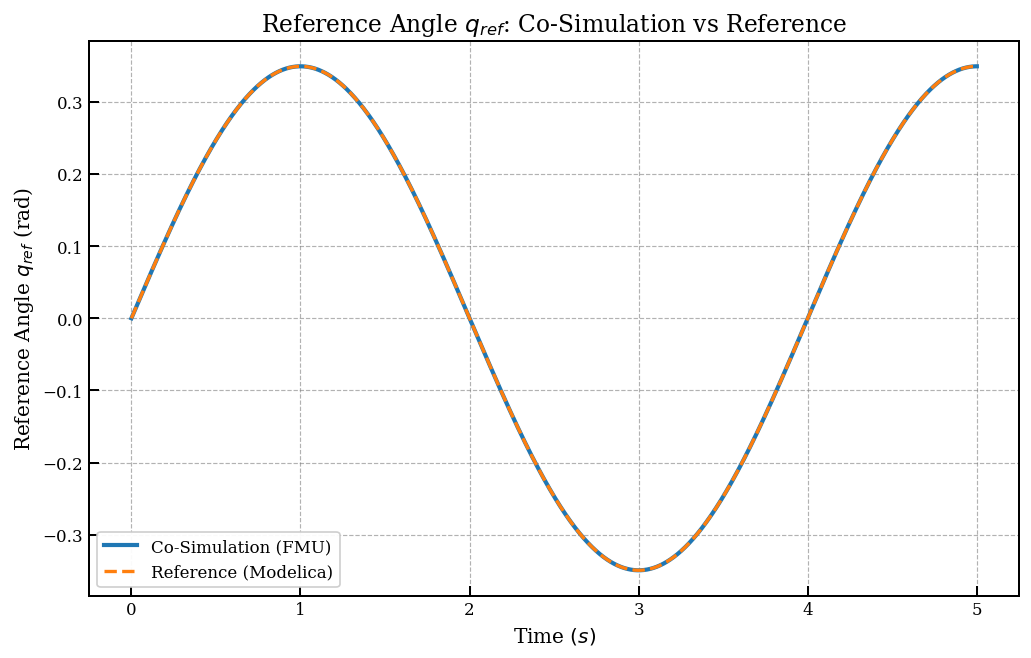

In [25]:
t_vals_cs, q_ref_cs = zip(*ref.outputs['q_ref'].history)
t_vals_cs = np.array(t_vals_cs)
q_ref_cs = np.array(q_ref_cs)

t_vals_ref = np.array(results['time'])
q_ref_vals_ref = np.array(results['reference.q_ref'])
q_ref_vals_ref_interp = np.interp(t_vals_cs, t_vals_ref, q_ref_vals_ref)

denom = np.max(np.abs(q_ref_vals_ref_interp))
q_ref_error = (q_ref_cs - q_ref_vals_ref_interp) / denom

max_error = np.max(np.abs(q_ref_error))
print(f"Maximum relative error in q_ref: {max_error:.3e}")

plt.figure(figsize=(10, 6))
plt.plot(t_vals_cs, q_ref_cs, label='Co-Simulation (FMU)', linewidth=2.5)
plt.plot(t_vals_ref, q_ref_vals_ref, '--', label='Reference (Modelica)', linewidth=2)
plt.xlabel('Time $(s)$')
plt.ylabel('Reference Angle $q_{ref}$ (rad)')
plt.title('Reference Angle $q_{ref}$: Co-Simulation vs Reference')
plt.legend()
plt.grid(True)
plt.show()

Maximum absolute error in Uq_ref: 1.176e-02


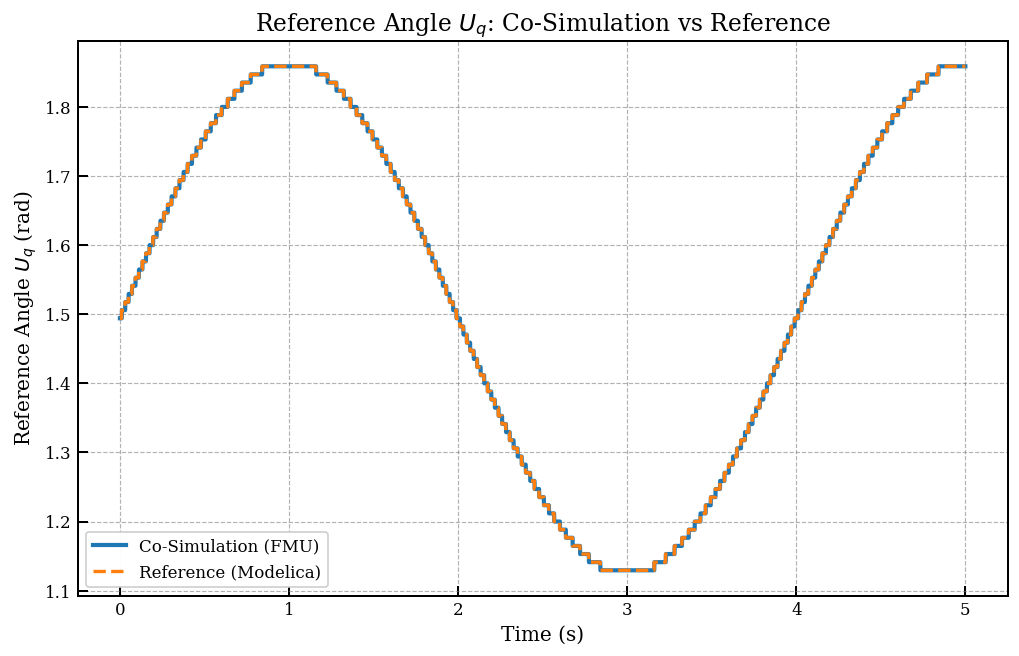

In [26]:
# Sensor Ref Uq
t_vals_cs, Uq_ref_cs = zip(*sensor_ref.outputs['U_q'].history)
t_vals_cs = np.array(t_vals_cs)
Uq_ref_cs = np.array([val.magnitude for val in Uq_ref_cs])

t_vals_ref = np.array(results['time'])
Uq_ref_ref = np.array(results['sensor_ref.U_q'])

Uq_ref_ref_interp = np.interp(t_vals_cs, t_vals_ref, Uq_ref_ref)
Uq_ref_error = Uq_ref_cs - Uq_ref_ref_interp
max_error = np.max(np.abs(Uq_ref_error))
print(f"Maximum absolute error in Uq_ref: {max_error:.3e}")

plt.figure(figsize=(10, 6))
plt.plot(t_vals_cs, Uq_ref_cs, label='Co-Simulation (FMU)', linewidth=2.5)
plt.plot(t_vals_ref, Uq_ref_ref, '--', label='Reference (Modelica)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Reference Angle $U_{q}$ (rad)')
plt.title('Reference Angle $U_{q}$: Co-Simulation vs Reference')
plt.legend()
plt.grid(True)
plt.show()

Maximum relative error in Uq_state: 6.329e-03


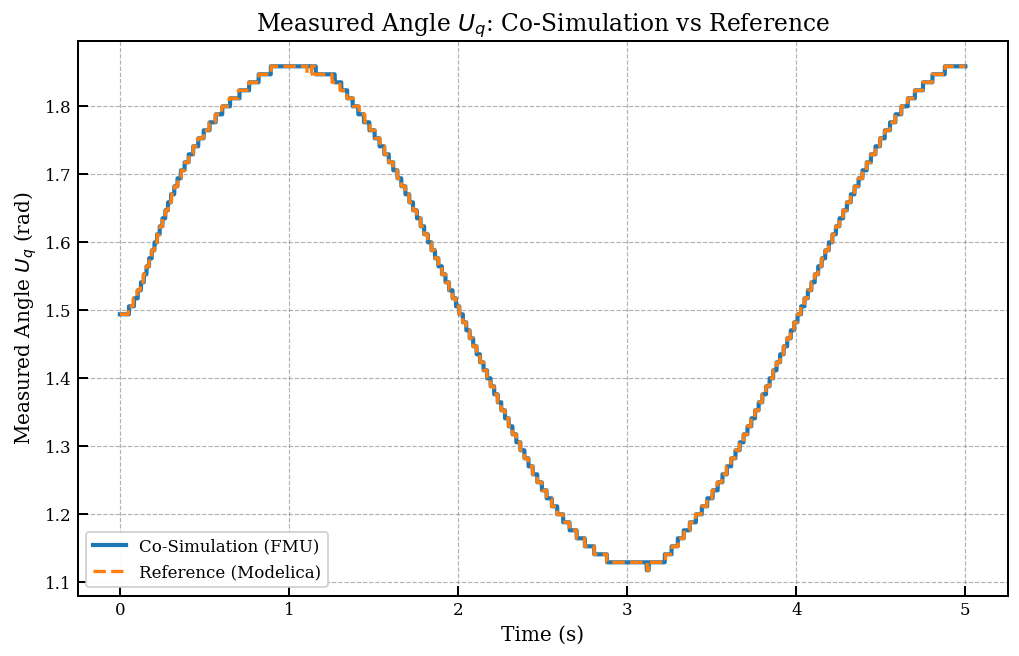

In [27]:
# Sensor State Uq
t_vals_cs, Uq_state_cs = zip(*sensor_state.outputs['U_q'].history)
t_vals_cs = np.array(t_vals_cs)

Uq_state_cs = np.array([val.magnitude for val in Uq_state_cs])
t_vals_ref = np.array(results['time'])

Uq_state_vals_ref = np.array(results['sensor_state.U_q'])
Uq_state_vals_ref_interp = np.interp(t_vals_cs, t_vals_ref, Uq_state_vals_ref)
denom = np.max(np.abs(Uq_state_vals_ref_interp))
Uq_state_error = (Uq_state_cs - Uq_state_vals_ref_interp) / denom
max_error = np.max(np.abs(Uq_state_error))
print(f"Maximum relative error in Uq_state: {max_error:.3e}")

plt.figure(figsize=(10, 6))
plt.plot(t_vals_cs, Uq_state_cs, label='Co-Simulation (FMU)', linewidth=2.5)
plt.plot(t_vals_cs, Uq_state_vals_ref_interp, '--', label='Reference (Modelica)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Measured Angle $U_{q}$ (rad)')
plt.title('Measured Angle $U_{q}$: Co-Simulation vs Reference')
plt.legend()
plt.grid(True)
plt.show()

Maximum relative error in u_pid: 1.494e+00


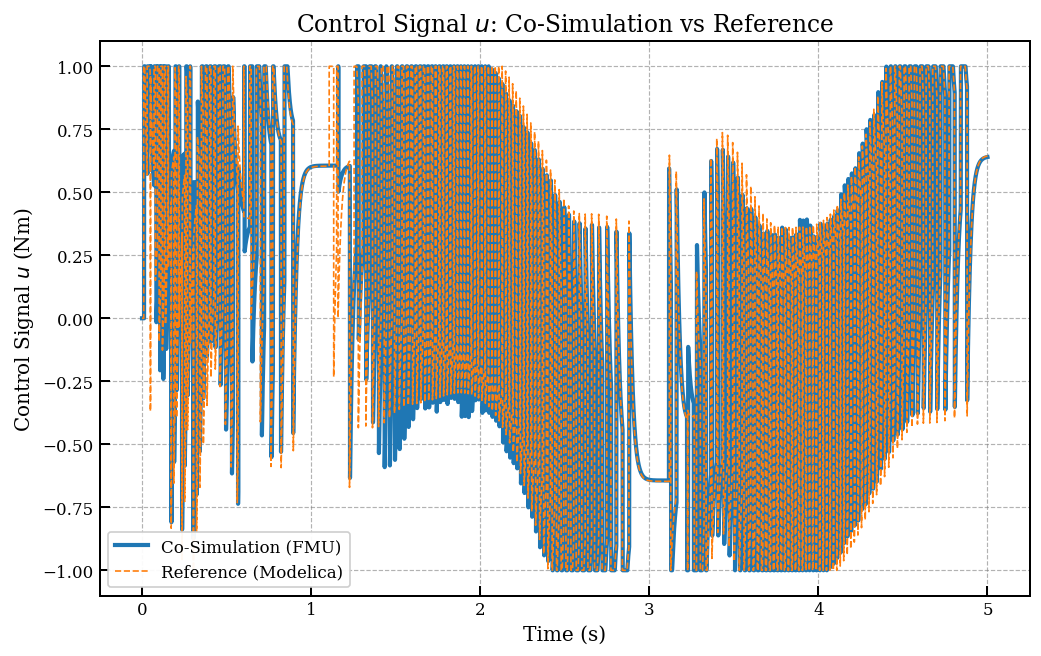

In [28]:
# PID u
t_vals_cs, u_pid_cs = zip(*pid.outputs['u'].history)
t_vals_cs = np.array(t_vals_cs)
u_pid_cs = np.array(u_pid_cs)

t_vals_ref = np.array(results['time'])
u_pid_vals_ref = np.array(results['pid.u'])
u_pid_vals_ref_interp = np.interp(t_vals_cs, t_vals_ref, u_pid_vals_ref)

denom = np.max(np.abs(u_pid_vals_ref_interp))
u_pid_error = (u_pid_cs - u_pid_vals_ref_interp) / denom

max_error = np.max(np.abs(u_pid_error))
print(f"Maximum relative error in u_pid: {max_error:.3e}")

plt.figure(figsize=(10, 6))
plt.plot(t_vals_cs, u_pid_cs, label='Co-Simulation (FMU)', linewidth=2.5)
plt.plot(t_vals_ref, u_pid_vals_ref, '--', label='Reference (Modelica)', linewidth=1)
plt.xlabel('Time (s)')
plt.ylabel('Control Signal $u$ (Nm)')
plt.title('Control Signal $u$: Co-Simulation vs Reference')
plt.legend()
plt.grid(True)
plt.show()

Maximum relative error in torque_drive: 1.240e+00


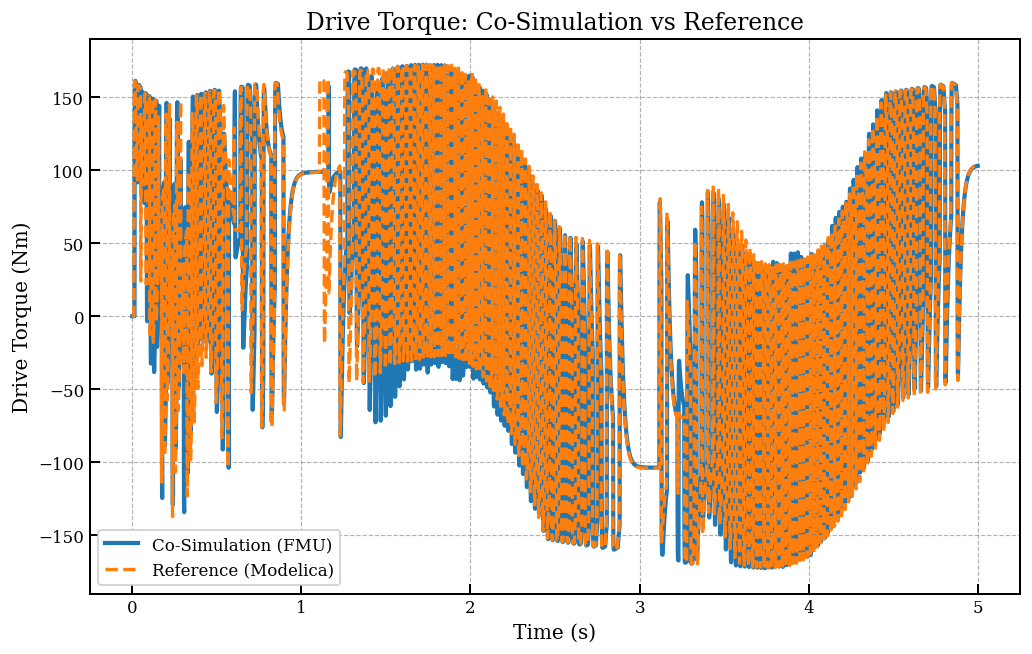

In [29]:
# Drive torque
t_vals_cs, torque_drive_cs = zip(*drive.outputs['torque'].history)
t_vals_cs = np.array(t_vals_cs)
torque_drive_cs = np.array([val.magnitude for val in torque_drive_cs])

t_vals_ref = np.array(results['time'])
torque_drive_vals_ref = np.array(results['drive.torque'])
torque_drive_vals_ref_interp = np.interp(t_vals_cs, t_vals_ref, torque_drive_vals_ref)
denom = np.max(np.abs(torque_drive_vals_ref_interp))
torque_drive_error = (torque_drive_cs - torque_drive_vals_ref_interp) / denom

max_error = np.max(np.abs(torque_drive_error))
print(f"Maximum relative error in torque_drive: {max_error:.3e}")

plt.figure(figsize=(10, 6))
plt.plot(t_vals_cs, torque_drive_cs, label='Co-Simulation (FMU)', linewidth=2.5)
plt.plot(t_vals_cs, torque_drive_vals_ref_interp, '--', label='Reference (Modelica)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Drive Torque (Nm)')
plt.title('Drive Torque: Co-Simulation vs Reference')
plt.legend()
plt.grid(True)
plt.show()

Maximum relative error in q_state: 1.147e-02


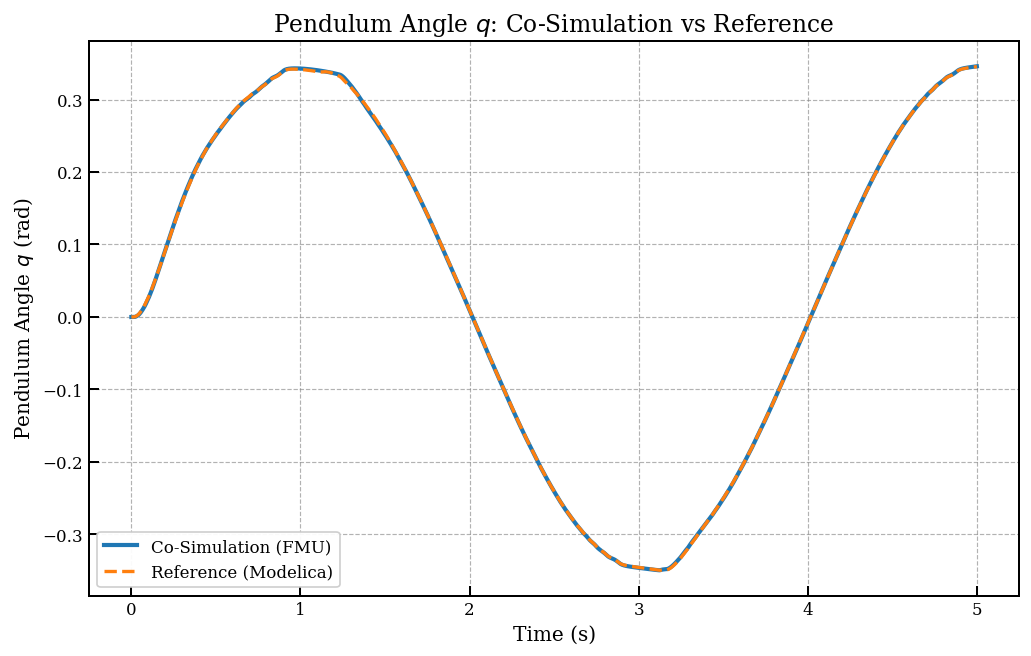

In [30]:
# Pendulum q
t_vals_cs, q_state_cs = zip(*pendulum.outputs['q'].history)
t_vals_cs = np.array(t_vals_cs)
q_state_cs = np.array([val.magnitude for val in q_state_cs])

t_vals_ref = np.array(results['time'])
q_state_vals_ref = np.array(results['pendulum.q'])
q_state_vals_ref_interp = np.interp(t_vals_cs, t_vals_ref, q_state_vals_ref)

denom = np.max(np.abs(q_state_vals_ref_interp))
q_state_error = (q_state_cs - q_state_vals_ref_interp) / denom

max_error = np.max(np.abs(q_state_error))
print(f"Maximum relative error in q_state: {max_error:.3e}")

plt.figure(figsize=(10, 6))
plt.plot(t_vals_cs, q_state_cs, label='Co-Simulation (FMU)', linewidth=2.5)
plt.plot(t_vals_ref, q_state_vals_ref, '--', label='Reference (Modelica)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Pendulum Angle $q$ (rad)')
plt.title('Pendulum Angle $q$: Co-Simulation vs Reference')
plt.legend()
plt.grid(True)
plt.show()
